In [1]:
import fluid_flow_1d_lofi as lofi
import fluid_flow_1d_hifi_eval as hifi
import matplotlib.pyplot as plt
import importlib

Succesfully imported fluid_flow_1d_lofi


In [81]:
importlib.reload(lofi);
importlib.reload(hifi);

Succesfully imported fluid_flow_1d_lofi


In [2]:
k0 = lofi.interpolate(lofi.Expression("pow(x[0], 2)", degree=2), lofi.K).vector()[:]
kt_in = lofi.interpolate(lofi.Expression("pow(x[0], 3)", degree=2), lofi.K).vector()[:]
k0_in = lofi.interpolate(lofi.Expression("pow(x[0], 4)", degree=2), lofi.K).vector()[:]

In [119]:
hess_exact = lofi.apply_rs_hessian(k0_in, k0).flatten()
norm_hess_exact = lofi.np.linalg.norm(hess_exact)

In [103]:
dJ = lambda m: lofi.J_hat_np(m)*0 + lofi.J_hat_np.derivative(forget=None)

In [125]:
epsilon=0.1
hess_fd = (dJ(k0 + epsilon * k0_in) - dJ(k0 - epsilon * k0_in)) / (2 * epsilon)

print("Hessian Relative Diff: ", lofi.np.linalg.norm(hess_fd - hess_exact)/norm_hess_exact)

Hessian Relative Diff:  1.8171551589284304e-14


In [3]:
# Solve initial iterate for inverse problem (used for taping adjoints)
k0_guess = lofi.fenics_convert(k0, "function", lofi.K);
k_n = lofi.state_solve(k0_guess, return_type = "function", plot_k=False, verbose=False, annotate=True);

# Set up inverse problem
J_inv = lofi.J(k0_guess, k_n)
control = lofi.Control(k0_guess)
J_hat = lofi.ReducedFunctional(J_inv, control)

# Solve Inverse Problem
with lofi.stop_verbose():
    k0_opt_lofi = lofi.minimize(J_hat, method="Newton-CG", callback=lofi.callback_call(J_hat), tol=1e-3, options={"disp": True})


Iteration  Objective Value      Gradient Norm  
---------------------------------------------
1          0.008899             0.001426       
2          0.000820             0.000074       
3          0.000759             0.000003       
4          0.000759             0.000000       
5          0.000759             0.000000       
Optimization terminated successfully.
         Current function value: 0.000759
         Iterations: 5
         Function evaluations: 5
         Gradient evaluations: 5
         Hessian evaluations: 25


In [47]:
# kt_lofi = lofi.state_solve(k0, "vector");
# u_end_lofi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_lofi.vector(), 0.1)
# print(u_end_lofi.vector()[:])
# plt.plot(u_end_lofi.vector()[:])


# kt_midfi = lofi.state_solve(k0, "vector");
# u_end_midfi = lofi.Function(lofi.U)
# lofi.u_timeseries.retrieve(u_end_midfi.vector(), 0.1)
# print(u_end_midfi.vector()[:])
# plt.plot(u_end_midfi.vector()[:])

In [48]:
# kt_hifi_1 = hifi.state_solve(k0, "vector");
# kt_lofi_1 = lofi.state_solve(k0, "vector");
# disc_k0_1 = kt_hifi_1 - kt_lofi_1

kt_lofi_2 = lofi.state_solve(k0, "vector");
kt_hifi_2 = hifi.state_solve(k0, "vector");
disc_k0_2 = kt_hifi_2 - kt_lofi_2

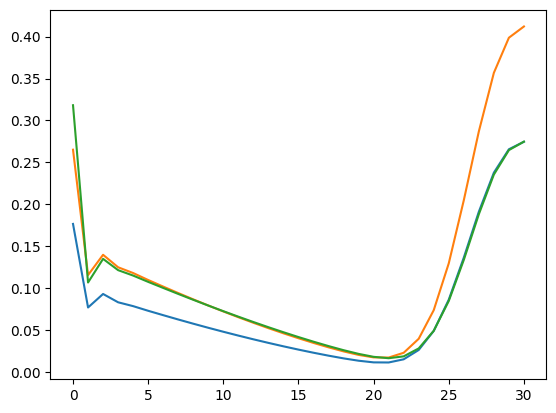

In [57]:
plt.plot(disc_k0_1)
plt.plot(1.5*disc_k0_1)
plt.plot(disc_k0_2)